# 01 — Exploratory Data Analysis and Preprocessing

## Objective

This notebook prepares the Data Science Weekly conversion dataset for supervised machine learning.

The objectives are to:

* inspect the dataset structure and assess data quality;
* identify the target variable and relevant predictive features;
* analyze the conversion rate and class balance;
* investigate numerical, categorical, and binary features through focused exploratory analysis;
* identify missing values, repeated observations, potential identifiers, and unusual values;
* define a reproducible baseline preprocessing strategy;
* create a stratified internal train/test split for model development and final internal evaluation.

The resulting data foundation and preprocessing strategy will support baseline modeling and subsequent model optimization in the next notebook.

## Methodology

The project follows a **supervised binary classification** approach because historical observations contain a known conversion outcome and the objective is to predict whether an unseen visitor will convert.

The competition's primary evaluation metric is the **F1-score**, which balances precision and recall. Model comparison and optimization will therefore prioritize F1 rather than accuracy.

The core workflow is:

**Labeled competition data → data quality assessment → exploratory analysis → stratified train/test split → baseline preprocessing → classification**

All preprocessing steps that learn parameters from the data will be fitted on training data only to prevent data leakage.

The competition `conversion_data_test.csv` dataset is kept separate from the internal test split. It contains no target labels and will only be used after final model selection to generate competition predictions.

The preprocessing strategy defined in this notebook provides a reproducible starting point for the baseline model. Model-specific preprocessing and targeted feature engineering may be evaluated later if they are justified by model performance and cross-validation results.

## Notebook Structure

1. Imports, configuration, and data loading
2. Initial dataset inspection
3. Data quality assessment
4. Target and class-balance analysis
5. Focused exploratory data analysis
6. Feature and preprocessing decisions
7. Stratified train/test split
8. Preprocessing pipeline
9. Conclusion and next steps



In [33]:
# Imports and reproducibility
# ---------------------------------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone


# Reproducibility settings
# ---------------------------------------------------------------------------

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)


# Project paths
# ---------------------------------------------------------------------------

TRAIN_DATA_PATH = Path("../data/raw/conversion_data_train.csv")
TEST_DATA_PATH = Path("../data/raw/conversion_data_test.csv")
FIGURES_PATH = Path("../outputs/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


# Package versions and configuration
# ---------------------------------------------------------------------------

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Random state: {RANDOM_STATE}")
print(f"Training data path: {TRAIN_DATA_PATH}")
print(f"Competition test data path: {TEST_DATA_PATH}")

NumPy version: 2.5.2
Pandas version: 3.0.5
Random state: 42
Training data path: ..\data\raw\conversion_data_train.csv
Competition test data path: ..\data\raw\conversion_data_test.csv


## 1. Data Loading and Initial Inspection

The first step is to load the labeled training dataset and the unlabeled competition test dataset and inspect their structure before making any preprocessing or modeling decisions.

The analysis will verify:

* dataset dimensions and column names;
* data types;
* the target variable;
* the distinction between labeled training data and unlabeled competition data;
* whether both datasets share the expected feature structure.

The competition test dataset will remain separate from model development and will only be used later to generate final competition predictions.


In [2]:
# Data loading
# ---------------------------------------------------------------------------

train_data = pd.read_csv(TRAIN_DATA_PATH)
competition_test_data = pd.read_csv(TEST_DATA_PATH)


# Dataset dimensions
# ---------------------------------------------------------------------------

print(f"Training dataset shape: {train_data.shape}")
print(f"Competition test dataset shape: {competition_test_data.shape}")

Training dataset shape: (284580, 6)
Competition test dataset shape: (31620, 5)


In [3]:
# Column names and data types
# ---------------------------------------------------------------------------

print("Training dataset:")
train_data.info()

print("\nCompetition test dataset:")
competition_test_data.info()

Training dataset:
<class 'pandas.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   country              284580 non-null  str  
 1   age                  284580 non-null  int64
 2   new_user             284580 non-null  int64
 3   source               284580 non-null  str  
 4   total_pages_visited  284580 non-null  int64
 5   converted            284580 non-null  int64
dtypes: int64(4), str(2)
memory usage: 13.0 MB

Competition test dataset:
<class 'pandas.DataFrame'>
RangeIndex: 31620 entries, 0 to 31619
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   country              31620 non-null  str  
 1   age                  31620 non-null  int64
 2   new_user             31620 non-null  int64
 3   source               31620 non-null  str  
 4   total_pages_visited  31620 

### Initial observations

The labeled training dataset contains **284,580 observations and 6 columns**, while the competition test dataset contains **31,620 observations and 5 columns**.

The additional training column is `converted`, confirming it as the target variable. The prediction problem therefore uses five input features:

* `country`
* `age`
* `new_user`
* `source`
* `total_pages_visited`

The initial data types suggest that `country` and `source` are categorical variables, while `age` and `total_pages_visited` are numerical. The `new_user` variable is stored as an integer and will be inspected further to confirm whether it behaves as a binary indicator.

No missing values are visible from the initial dataset summary.

The competition test dataset contains the same five predictor columns and no target variable, as expected. It will remain separate from model development and internal evaluation.


In [4]:
# Preview the datasets
# ---------------------------------------------------------------------------

display(train_data.head())

display(competition_test_data.head())

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


,country,age,new_user,source,total_pages_visited
0,UK,28,0,Seo,16
1,UK,22,1,Direct,5
2,China,32,1,Seo,1
3,US,32,1,Ads,6
4,China,25,0,Seo,3


## 2. Data Quality Assessment

Before exploratory analysis, the dataset is checked for issues that could affect preprocessing or model validity.

The assessment focuses on:

* missing values;
* duplicate observations;
* unique values and categorical cardinality;
* validity of binary variables;
* numerical ranges and potentially unusual values.

These checks help identify whether cleaning, feature exclusion, or additional preprocessing is required before modeling.


In [6]:
# Missing values
# ---------------------------------------------------------------------------

missing_train = train_data.isna().sum()
missing_competition = competition_test_data.isna().sum()

print("Missing values — training data:")
print(missing_train)

print("\nMissing values — competition test data:")
print(missing_competition)


# Duplicate observations
# ---------------------------------------------------------------------------

train_duplicates = train_data.duplicated().sum()
competition_duplicates = competition_test_data.duplicated().sum()

print(f"\nDuplicate rows — training data: {train_duplicates:,}")
print(f"Duplicate rows — competition test data: {competition_duplicates:,}")

Missing values — training data:
country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64

Missing values — competition test data:
country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
dtype: int64

Duplicate rows — training data: 268,769
Duplicate rows — competition test data: 24,140


In [7]:
# Unique values and cardinality
# ---------------------------------------------------------------------------

for column in train_data.columns:
    unique_count = train_data[column].nunique()
    print(f"{column}: {unique_count} unique value(s)")

country: 4 unique value(s)
age: 60 unique value(s)
new_user: 2 unique value(s)
source: 3 unique value(s)
total_pages_visited: 29 unique value(s)
converted: 2 unique value(s)


In [8]:
# Values of categorical and binary variables
# ---------------------------------------------------------------------------

for column in ["country", "source", "new_user", "converted"]:
    print(f"\n{column}:")
    print(train_data[column].value_counts(dropna=False).sort_index())


country:
country
China       69122
Germany     11693
UK          43641
US         160124
Name: count, dtype: int64

source:
source
Ads        80027
Direct     65076
Seo       139477
Name: count, dtype: int64

new_user:
new_user
0     89514
1    195066
Name: count, dtype: int64

converted:
converted
0    275400
1      9180
Name: count, dtype: int64


### Data quality findings

No missing values are present in either the training or competition test dataset.

A large number of identical rows is observed. However, these rows should not automatically be treated as data-quality errors. The dataset contains only a small number of relatively low-cardinality visitor characteristics and no unique visitor or session identifier. Different visitors can therefore legitimately share the same observed feature values. Removing these observations could distort the underlying data distribution, so they are retained.

The categorical features have low cardinality, with **4 countries** and **3 acquisition sources**. Both `new_user` and the target `converted` contain two values, consistent with binary indicators.

The target is strongly imbalanced: only **9,180 of 284,580 observations** correspond to conversions, representing approximately **3.23%** of the training dataset. This imbalance will be considered explicitly during model evaluation and supports the use of F1-score rather than accuracy as the primary performance metric.


In [9]:
# Numerical feature summary
# ---------------------------------------------------------------------------

numerical_features = ["age", "total_pages_visited"]

train_data[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,284580.0,30.564203,8.266789,17.0,24.0,30.0,36.0,123.0
total_pages_visited,284580.0,4.873252,3.341995,1.0,2.0,4.0,7.0,29.0


In [10]:
# Numerical feature ranges
# ---------------------------------------------------------------------------

for column in numerical_features:
    print(
        f"{column}: "
        f"min = {train_data[column].min()}, "
        f"max = {train_data[column].max()}, "
        f"median = {train_data[column].median()}"
    )

age: min = 17, max = 123, median = 30.0
total_pages_visited: min = 1, max = 29, median = 4.0


In [11]:
# Investigate unusually high age values
# ---------------------------------------------------------------------------

high_age_counts = (
    train_data.loc[train_data["age"] > 80, "age"]
    .value_counts()
    .sort_index()
)

print("Training observations with age > 80:")
print(high_age_counts)

print(
    f"\nTotal observations with age > 80: "
    f"{(train_data['age'] > 80).sum():,}"
)


# Check the competition test dataset as well
# ---------------------------------------------------------------------------

competition_high_age_counts = (
    competition_test_data.loc[
        competition_test_data["age"] > 80, "age"
    ]
    .value_counts()
    .sort_index()
)

print("\nCompetition test observations with age > 80:")
print(competition_high_age_counts)

print(
    f"\nTotal competition observations with age > 80: "
    f"{(competition_test_data['age'] > 80).sum():,}"
)

Training observations with age > 80:
age
111    1
123    1
Name: count, dtype: int64

Total observations with age > 80: 2

Competition test observations with age > 80:
Series([], Name: count, dtype: int64)

Total competition observations with age > 80: 0


### Numerical data quality findings

The numerical features are generally plausible. `total_pages_visited` ranges from 1 to 29 visits, while `age` has a median of 30 years.

Two anomalous age values were identified in the training dataset: **111 and 123**, each occurring once. No observations above 80 years are present in the competition test dataset.

These two records represent a negligible proportion of the training data and are treated as implausible age values. They will therefore be removed from the labeled dataset rather than imputed or capped.

No observations are removed based on the target variable or model performance.


In [12]:
# Remove implausible age observations
# ---------------------------------------------------------------------------

initial_train_size = len(train_data)

train_data = (
    train_data.loc[train_data["age"] <= 80]
    .reset_index(drop=True)
)

removed_rows = initial_train_size - len(train_data)

print(f"Rows removed: {removed_rows}")
print(f"Training dataset shape after cleaning: {train_data.shape}")
print(f"Maximum age after cleaning: {train_data['age'].max()}")

Rows removed: 2
Training dataset shape after cleaning: (284578, 6)
Maximum age after cleaning: 79


## 3. Target and Class Balance Analysis

The target variable, `converted`, indicates whether a visitor subscribed to the newsletter:

* `0` — no conversion;
* `1` — conversion.

Before modeling, the target distribution must be examined to determine the degree of class imbalance.

This is particularly important because the competition is evaluated using the **F1-score**, which balances precision and recall and is more informative than accuracy when the positive class is relatively rare.


In [13]:
# Target distribution
# ---------------------------------------------------------------------------

target_counts = train_data["converted"].value_counts().sort_index()
target_proportions = (
    train_data["converted"]
    .value_counts(normalize=True)
    .sort_index()
)

conversion_rate = train_data["converted"].mean()

print("Target counts:")
print(target_counts)

print("\nTarget proportions:")
print(target_proportions)

print(f"\nConversion rate: {conversion_rate:.2%}")

Target counts:
converted
0    275400
1      9178
Name: count, dtype: int64

Target proportions:
converted
0    0.967749
1    0.032251
Name: proportion, dtype: float64

Conversion rate: 3.23%


In [14]:
# Majority-class baseline accuracy
# ---------------------------------------------------------------------------

majority_class_accuracy = target_proportions.max()

print(
    "Accuracy of an always 'no conversion' classifier: "
    f"{majority_class_accuracy:.2%}"
)

Accuracy of an always 'no conversion' classifier: 96.77%


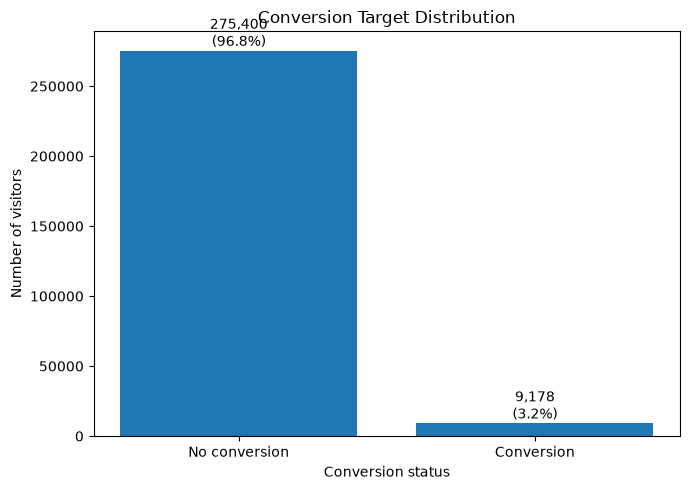

Figure saved to: ..\outputs\figures\target_distribution.png


In [17]:
# Target distribution visualization
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["No conversion", "Conversion"],
    target_counts.values,
)

ax.set_title("Conversion Target Distribution")
ax.set_xlabel("Conversion status")
ax.set_ylabel("Number of visitors")

for bar, count in zip(bars, target_counts.values):
    percentage = count / len(train_data)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.1%})",
        ha="center",
        va="bottom",
    )

plt.tight_layout()

figure_path = FIGURES_PATH / "target_distribution.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

### Target analysis findings

The dataset is strongly imbalanced: **96.77% of visitors did not convert**, while only **3.23% converted**.

This imbalance makes accuracy unsuitable as the primary evaluation metric. A classifier that predicts no conversion for every visitor would achieve **96.77% accuracy** despite failing to identify any actual conversions.

The project will therefore use **F1-score as the primary model-selection metric**, with precision, recall, and the confusion matrix used as complementary diagnostics.


## 4. Focused Exploratory Data Analysis

The remaining exploratory analysis focuses on relationships between the predictor variables and conversion rather than producing exhaustive univariate plots.

The objectives are to:

* identify features associated with higher or lower conversion rates;
* understand the distributions of the numerical variables;
* compare conversion behavior across categorical and binary visitor characteristics;
* identify patterns that may influence preprocessing and model interpretation.

Because the objective is prediction rather than causal inference, observed relationships are interpreted as **predictive associations**, not causal effects.


In [18]:
# Pages visited by conversion status
# ---------------------------------------------------------------------------

pages_by_conversion = (
    train_data
    .groupby("converted")["total_pages_visited"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

pages_by_conversion

,count,mean,median,std,min,max
converted,,,,,,
0,275400,4.550359,4.0,2.790450,1,20
1,9178,14.560471,14.0,3.959737,2,29


In [20]:
# Conversion rate by number of pages visited
# ---------------------------------------------------------------------------

conversion_by_pages = (
    train_data
    .groupby("total_pages_visited")["converted"]
    .agg(conversion_rate="mean", visitors="size")
    .reset_index()
)

conversion_by_pages["conversion_rate"] *= 100

conversion_by_pages

,total_pages_visited,conversion_rate,visitors
0,1,0.000000,36637
1,2,0.022758,39546
2,3,0.027873,39465
3,4,0.078552,36918
4,5,0.156183,32654
5,6,0.345614,27198
6,7,0.658393,21112
7,8,1.528412,15768
8,9,3.317536,10972
9,10,6.032007,7311


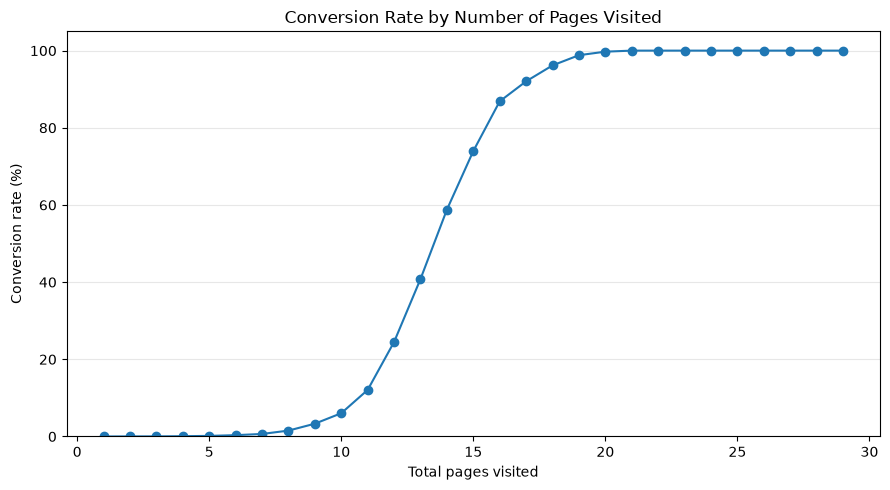

Figure saved to: ..\outputs\figures\conversion_rate_by_pages.png


In [21]:
# Conversion rate by number of pages visited
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    conversion_by_pages["total_pages_visited"],
    conversion_by_pages["conversion_rate"],
    marker="o",
)

ax.set_title("Conversion Rate by Number of Pages Visited")
ax.set_xlabel("Total pages visited")
ax.set_ylabel("Conversion rate (%)")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

figure_path = FIGURES_PATH / "conversion_rate_by_pages.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

Figure: How conversion evolves as page visits increase?

### Pages visited and conversion

`total_pages_visited` shows a strong positive association with conversion.

Visitors who did not convert viewed a median of **4 pages**, compared with **14 pages** among visitors who converted. The conversion rate remains very low for visitors viewing only a few pages, then increases sharply as the number of pages visited rises.

For example, the observed conversion rate increases from approximately **3.3% at 9 pages** to **24.5% at 12 pages**, **74.0% at 15 pages**, and more than **90% from 17 pages onward**.

Conversion rates of 100% at the highest page counts should be interpreted cautiously because these values are based on relatively small numbers of visitors.

Overall, `total_pages_visited` appears to be a particularly informative predictor of conversion. This relationship is predictive rather than necessarily causal: visiting more pages may indicate stronger pre-existing purchase or subscription intent rather than cause conversion.


In [22]:
# Age by conversion status
# ---------------------------------------------------------------------------

age_by_conversion = (
    train_data
    .groupby("converted")["age"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

age_by_conversion

,count,mean,median,std,min,max
converted,,,,,,
0,275400,30.697422,30.0,8.270090,17,79
1,9178,26.547941,25.0,6.958676,17,61


In [23]:
# Conversion rate by age group
# ---------------------------------------------------------------------------

age_bins = [16, 24, 34, 44, 54, 64, 80]
age_labels = [
    "17–24",
    "25–34",
    "35–44",
    "45–54",
    "55–64",
    "65+",
]

age_groups = pd.cut(
    train_data["age"],
    bins=age_bins,
    labels=age_labels,
)

conversion_by_age = (
    train_data
    .assign(age_group=age_groups)
    .groupby("age_group", observed=True)["converted"]
    .agg(conversion_rate="mean", visitors="size")
    .reset_index()
)

conversion_by_age["conversion_rate"] *= 100

conversion_by_age

,age_group,conversion_rate,visitors
0,17–24,5.541880,75155
1,25–34,3.054698,122729
2,35–44,1.598347,69697
3,45–54,0.908509,15630
4,55–64,0.601504,1330
5,65+,0.000000,37


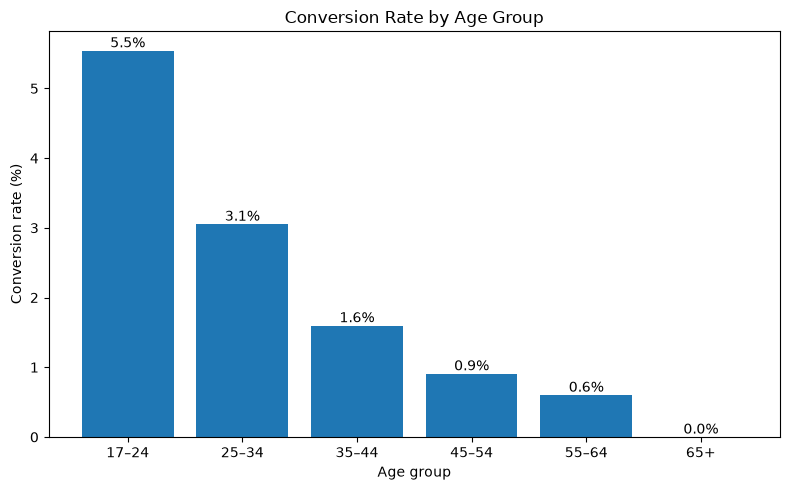

Figure saved to: ..\outputs\figures\conversion_rate_by_age_group.png


In [24]:
# Conversion rate by age group
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    conversion_by_age["age_group"].astype(str),
    conversion_by_age["conversion_rate"],
)

ax.set_title("Conversion Rate by Age Group")
ax.set_xlabel("Age group")
ax.set_ylabel("Conversion rate (%)")

for bar, rate in zip(bars, conversion_by_age["conversion_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()

figure_path = FIGURES_PATH / "conversion_rate_by_age_group.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

### Age and conversion

Age shows a negative association with conversion. Visitors who converted have a mean age of approximately **26.5 years**, compared with **30.7 years** among non-converters.

The conversion rate decreases consistently across the main age groups, from approximately **5.5% among visitors aged 17–24** to **3.1% for ages 25–34**, **1.6% for ages 35–44**, and below **1% for visitors aged 45 and above**.

The oldest age groups contain substantially fewer observations, particularly the `65+` group, so their conversion rates should be interpreted cautiously.

Overall, age appears to provide useful predictive information, although its relationship with conversion is less pronounced than that observed for `total_pages_visited`.


In [25]:
# Conversion rates for categorical and binary features
# ---------------------------------------------------------------------------

def summarize_conversion_by_feature(data, feature):
    """Return visitor counts and conversion rates by feature category."""
    summary = (
        data.groupby(feature)["converted"]
        .agg(visitors="size", conversions="sum", conversion_rate="mean")
        .reset_index()
    )

    summary["conversion_rate"] *= 100

    return summary.sort_values(
        "conversion_rate",
        ascending=False,
    ).reset_index(drop=True)


country_conversion = summarize_conversion_by_feature(
    train_data,
    "country",
)

source_conversion = summarize_conversion_by_feature(
    train_data,
    "source",
)

new_user_conversion = summarize_conversion_by_feature(
    train_data,
    "new_user",
)

display(country_conversion)
display(source_conversion)
display(new_user_conversion)

,country,visitors,conversions,conversion_rate
0,Germany,11692,729,6.235033
1,UK,43640,2290,5.247479
2,US,160124,6070,3.790812
3,China,69122,89,0.128758


,source,visitors,conversions,conversion_rate
0,Ads,80026,2784,3.478869
1,Seo,139476,4584,3.286587
2,Direct,65076,1810,2.781363


,new_user,visitors,conversions,conversion_rate
0,0,89512,6437,7.191215
1,1,195066,2741,1.405165


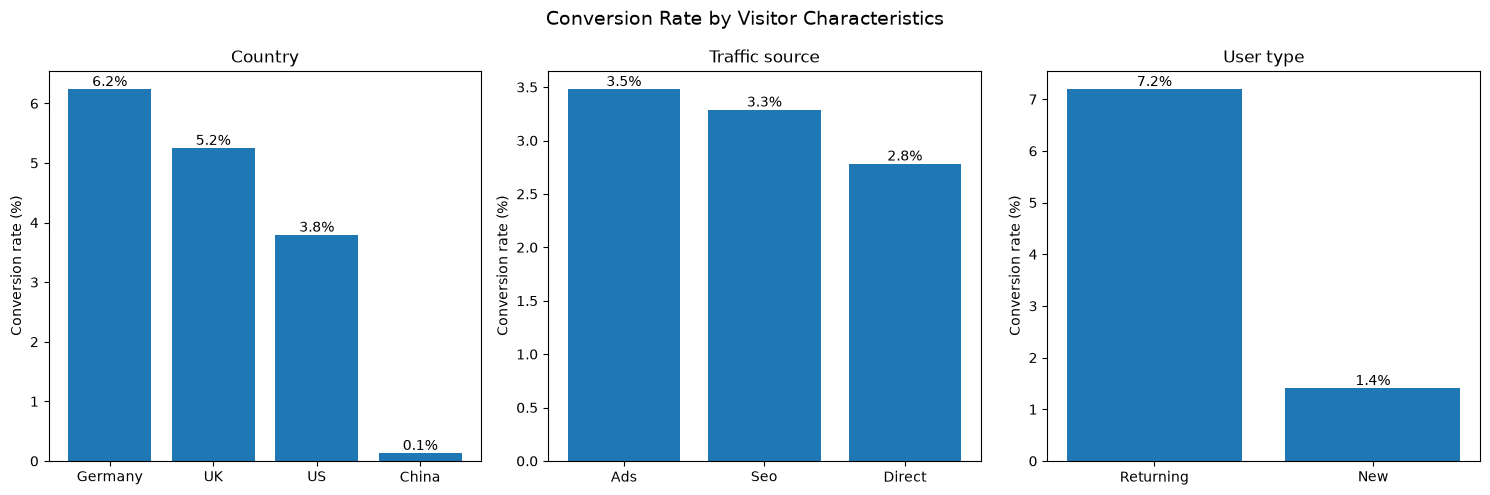

Figure saved to: ..\outputs\figures\conversion_rate_by_visitor_characteristics.png


In [26]:
# Conversion rates across categorical and binary features
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

feature_summaries = [
    (country_conversion, "country", "Country"),
    (source_conversion, "source", "Traffic source"),
    (new_user_conversion, "new_user", "User type"),
]

for ax, (summary, feature, title) in zip(axes, feature_summaries):
    labels = summary[feature].astype(str).tolist()

    if feature == "new_user":
        labels = [
            "Returning" if value == "0" else "New"
            for value in labels
        ]

    bars = ax.bar(
        labels,
        summary["conversion_rate"],
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Conversion rate (%)")

    for bar, rate in zip(bars, summary["conversion_rate"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{rate:.1f}%",
            ha="center",
            va="bottom",
        )

fig.suptitle(
    "Conversion Rate by Visitor Characteristics",
    fontsize=14,
)

plt.tight_layout()

figure_path = (
    FIGURES_PATH
    / "conversion_rate_by_visitor_characteristics.png"
)
plt.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

### Visitor characteristics and conversion

Conversion rates vary substantially across several visitor characteristics.

**Country** shows a pronounced association with conversion. Germany has the highest observed conversion rate at approximately **6.2%**, followed by the UK at **5.2%** and the US at **3.8%**. China has a substantially lower observed conversion rate of approximately **0.1%**.

**User status** is also strongly associated with conversion. Returning users convert at approximately **7.2%**, compared with only **1.4%** among new users.

Differences across **traffic sources** are more moderate. Visitors acquired through Ads have the highest observed conversion rate at approximately **3.5%**, followed closely by SEO at **3.3%**, while Direct traffic converts at approximately **2.8%**.

These results indicate that country and user status are likely to provide meaningful predictive information, while acquisition source may have a weaker contribution. These relationships are descriptive associations and should not be interpreted as causal effects.


## 5. Feature and Preprocessing Decisions

The exploratory analysis supports retaining all five available predictor variables:

* `country` — categorical;
* `age` — numerical;
* `new_user` — binary indicator;
* `source` — categorical;
* `total_pages_visited` — numerical.

No identifier or obvious leakage variable is present.

The categorical features `country` and `source` will be one-hot encoded so that they can be used by models such as logistic regression. Unknown categories will be ignored during transformation to ensure that unseen categories in future data do not cause preprocessing errors.

The numerical features `age` and `total_pages_visited` will be standardized for the logistic-regression baseline. `new_user` is already represented as a binary 0/1 indicator and does not require encoding.

No missing-value imputation is required because no missing values were identified in either dataset.

All preprocessing transformations that learn parameters from the data will be fitted on training data only through a scikit-learn pipeline, preventing information leakage from the internal test set.


## 6. Stratified Train/Test Split

The cleaned labeled dataset is divided into training and internal test sets before any preprocessing is fitted.

A **stratified split** is used because conversions represent only about 3.2% of observations. Stratification preserves approximately the same target distribution in both subsets.

The training set will be used for preprocessing, cross-validation, model comparison, and hyperparameter optimization. The internal test set will remain untouched during model development and will only be used to evaluate the selected model.

The separate competition test dataset is not involved in this split and remains reserved for final prediction generation.


In [28]:
# Features and target
# ---------------------------------------------------------------------------

X = train_data.drop(columns="converted")
y = train_data["converted"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature matrix shape: (284578, 5)
Target shape: (284578,)


In [29]:
# Stratified train/test split
# ---------------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training features shape: {X_train.shape}")
print(f"Internal test features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Internal test target shape: {y_test.shape}")

Training features shape: (227662, 5)
Internal test features shape: (56916, 5)
Training target shape: (227662,)
Internal test target shape: (56916,)


In [30]:
# Verify target distribution after splitting
# ---------------------------------------------------------------------------

split_distribution = pd.DataFrame(
    {
        "Full dataset": y.value_counts(normalize=True).sort_index(),
        "Training set": y_train.value_counts(normalize=True).sort_index(),
        "Internal test set": y_test.value_counts(normalize=True).sort_index(),
    }
)

split_distribution.index = ["No conversion", "Conversion"]
split_distribution = split_distribution * 100

split_distribution.round(3)

,Full dataset,Training set,Internal test set
No conversion,96.775,96.775,96.774
Conversion,3.225,3.225,3.226


### Split verification

The stratified 80/20 split produced **227,662 training observations** and **56,916 internal test observations**.

The conversion rate remains approximately **3.23%** in the full dataset, training set, and internal test set, confirming that stratification successfully preserved the original class distribution.

The internal test set will remain untouched during preprocessing decisions, cross-validation, and model optimization.


## 7. Preprocessing Pipeline

A reusable preprocessing strategy is defined for the logistic-regression baseline and other models requiring the same feature representation.

The predictors are handled according to their data type:

* `age` and `total_pages_visited` are numerical features and will be standardized for models that benefit from feature scaling;
* `country` and `source` are categorical features and will be one-hot encoded;
* `new_user` is already a binary 0/1 indicator and will be passed through unchanged.

`OneHotEncoder` is configured with `handle_unknown="ignore"` so that previously unseen categories can be processed safely.

### Modeling preparation

This preprocessing strategy provides a reproducible starting point for the logistic-regression baseline. In the modeling stage, alternative model-specific preprocessing and a limited number of hypothesis-driven engineered features may be evaluated where justified by the exploratory findings.

Any additional feature engineering will be retained only if it provides a meaningful and stable improvement in cross-validated predictive performance.




In [32]:
# Feature groups
# ---------------------------------------------------------------------------

numerical_features = [
    "age",
    "total_pages_visited",
]

categorical_features = [
    "country",
    "source",
]

binary_features = [
    "new_user",
]


# Preprocessing pipeline
# ---------------------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
        (
            "binary",
            "passthrough",
            binary_features,
        ),
    ],
    remainder="drop",
)

In [34]:

# Validate preprocessing on training data
# ---------------------------------------------------------------------------

preprocessor_check = clone(preprocessor)

X_train_transformed = preprocessor_check.fit_transform(X_train)

feature_names = preprocessor_check.get_feature_names_out()

print(f"Original training shape: {X_train.shape}")
print(f"Transformed training shape: {X_train_transformed.shape}")
print(f"Number of transformed features: {len(feature_names)}")

print("\nTransformed feature names:")
for feature_name in feature_names:
    print(f"- {feature_name}")

Original training shape: (227662, 5)
Transformed training shape: (227662, 10)
Number of transformed features: 10

Transformed feature names:
- numerical__age
- numerical__total_pages_visited
- categorical__country_China
- categorical__country_Germany
- categorical__country_UK
- categorical__country_US
- categorical__source_Ads
- categorical__source_Direct
- categorical__source_Seo
- binary__new_user


In [35]:
# Verify preprocessing compatibility with competition data
# ---------------------------------------------------------------------------

competition_transformed = preprocessor_check.transform(
    competition_test_data
)

print(
    "Transformed competition test shape: "
    f"{competition_transformed.shape}"
)

print(
    "Same number of transformed features: "
    f"{X_train_transformed.shape[1] == competition_transformed.shape[1]}"
)

Transformed competition test shape: (31620, 10)
Same number of transformed features: True


### Preprocessing validation

The baseline preprocessing strategy transforms the five original predictors into **10 model-ready features**.

The same fitted transformation produces 10 features for the competition test dataset, confirming that the training and competition datasets are compatible with the preprocessing strategy.

This validation step does not use the competition data to learn preprocessing parameters: the preprocessing object is fitted exclusively on the internal training data and only applied to the competition data through `transform()`.


## 8. Conclusion and Next Steps

This notebook established the data foundation for the conversion classification project.

### Key findings

* The cleaned labeled dataset contains **284,578 observations** and five predictor variables.
* Two implausible age observations (`111` and `123`) were removed from the training data.
* No missing values were identified. Repeated feature combinations were retained because no visitor or session identifier is available to establish that they represent erroneous duplicates.
* The target is strongly imbalanced, with a conversion rate of approximately **3.23%**.
* `total_pages_visited` shows the strongest observed association with conversion: visitors who convert tend to visit substantially more pages.
* Younger visitors and returning users show higher observed conversion rates.
* Conversion rates also vary substantially by country, while differences across acquisition sources are more moderate.
* These relationships are predictive associations and should not be interpreted as causal effects.

### Modeling preparation

The cleaned labeled data was divided using a stratified 80/20 train/test split, producing **227,662 observations for model development** and **56,916 observations for final internal evaluation**. The internal test set will remain untouched during model selection and hyperparameter optimization.

A baseline-compatible preprocessing strategy was defined for the original predictors. It standardizes the numerical features, one-hot encodes the categorical features, and retains the binary `new_user` indicator. The resulting transformation produces **10 model-ready features** and is compatible with the separate competition test dataset.

This preprocessing strategy provides a reproducible starting point for the logistic-regression baseline. Alternative model-specific preprocessing and a limited number of hypothesis-driven engineered features may be evaluated during modeling where justified by the exploratory findings.

Any additional feature engineering will be retained only if it provides a meaningful and stable improvement in cross-validated predictive performance.

### Next steps

The next notebook will focus on supervised classification and model optimization:

1. establish a logistic-regression baseline using the original predictors;
2. evaluate F1-score, precision, recall, confusion matrix, and cross-validation stability;
3. optimize logistic regression using a focused set of justified hyperparameters;
4. evaluate whether targeted feature engineering improves cross-validated performance;
5. compare the optimized linear approach with one justified nonlinear challenger;
6. select the final modeling strategy based on predictive performance, generalization, stability, and complexity.
